### Preprocesamiento de datos para construcción de modelo de Regresión Logística

In [177]:
#Importación de las librerías principales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [178]:
#Importación de la dataset filtrada desde el notebook EDA
intrusion_2 = pd.read_csv(r"C:\Users\ntama\Documentos\Data Science\Gen Data\Prueba\prueba-gendata\data\intrusion_eda.csv")
intrusion_2.head()

,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


In [179]:
##columnas categóricas y numnéricas en listas
num_var = list((intrusion_2.select_dtypes(include='number')).columns)
categ_var = list((intrusion_2.select_dtypes(include=object)).columns)
print("Variables numéricas: ", num_var)
print("Variables categóricas: ", categ_var)

Variables numéricas:  ['network_packet_size', 'login_attempts', 'session_duration', 'ip_reputation_score', 'failed_logins', 'unusual_time_access', 'attack_detected']
Variables categóricas:  ['protocol_type', 'encryption_used', 'browser_type']


### Transformación de variables numéricas

'network_packet_size': Se decide transformación boxcox después de probar con logarítmica y cuadrática y observar que se transforma en una distribución Sesgada a la izquierda

(array([ 462.,  764., 1541., 2178., 2146., 1491.,  694.,  208.,   49.,
           4.]),
 array([ 42.53312078,  98.68892335, 154.84472592, 211.00052849,
        267.15633106, 323.31213363, 379.4679362 , 435.62373877,
        491.77954134, 547.93534391, 604.09114648]),
 <BarContainer object of 10 artists>)

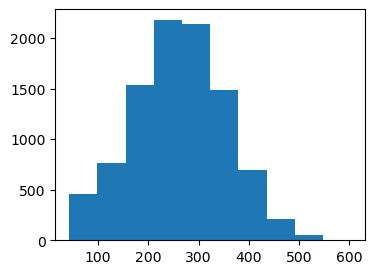

In [180]:
#transformación de la variable network_packet_size
from scipy.stats import boxcox
intrusion_2['network_packet_size'], _ = boxcox(intrusion_2['network_packet_size'])
plt.figure(figsize=(4,3))
plt.hist(data=intrusion_2, x='network_packet_size')

'login_attempts': Se decide transformación cuadrática produciendo una distribución más simétrica que la logarítmica.

(array([ 260.,  225.,  535., 1059., 1820., 2410., 2012.,  977.,  216.,
          23.]),
 array([ 6.52174216,  8.32739452, 10.13304687, 11.93869923, 13.74435159,
        15.55000395, 17.3556563 , 19.16130866, 20.96696102, 22.77261338,
        24.57826573]),
 <BarContainer object of 10 artists>)

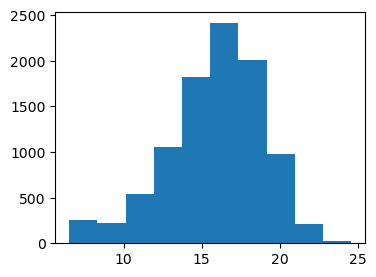

In [181]:
#transformación de la variable login_attempts
intrusion_2['login_attempts'] = np.sqrt(intrusion_2['network_packet_size'])
plt.figure(figsize=(4,3))
plt.hist(data=intrusion_2, x='login_attempts')

'session_duration': Transformación boxcox

In [182]:
print(np.min(intrusion_2['session_duration']))

0.5


(array([ 105.,  430., 1040., 1824., 2222., 2034., 1282.,  460.,  119.,
          21.]),
 array([-0.63265622,  3.0805462 ,  6.79374862, 10.50695105, 14.22015347,
        17.93335589, 21.64655832, 25.35976074, 29.07296317, 32.78616559,
        36.49936801]),
 <BarContainer object of 10 artists>)

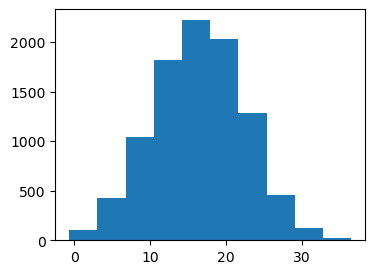

In [183]:
#transformación de la variable session_duration
intrusion_2['session_duration'], _ = boxcox(intrusion_2['session_duration'])
plt.figure(figsize=(4,3))
plt.hist(data=intrusion_2, x='session_duration')

'ip_reputation_score': Transformación boxcox

(array([ 404., 1070., 1453., 1579., 1665., 1378., 1072.,  611.,  245.,
          60.]),
 array([0.00249372, 0.06770053, 0.13290735, 0.19811416, 0.26332097,
        0.32852778, 0.3937346 , 0.45894141, 0.52414822, 0.58935503,
        0.65456185]),
 <BarContainer object of 10 artists>)

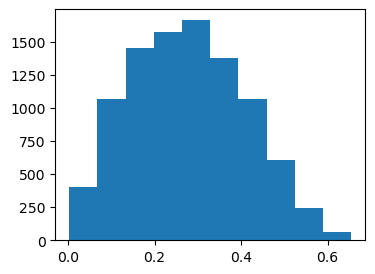

In [184]:
#transformación de la variable ip_reputation_score
intrusion_2['ip_reputation_score'] = np.log1p(intrusion_2['ip_reputation_score'])
plt.figure(figsize=(4,3))
plt.hist(data=intrusion_2, x='ip_reputation_score')

'failed_loggins': Transformación Logarítmica admitiendo ceros

(array([1578.,    0.,    0., 3383.,    0.,    0., 2992., 1261.,  290.,
          33.]),
 array([0.        , 0.17917595, 0.35835189, 0.53752784, 0.71670379,
        0.89587973, 1.07505568, 1.25423163, 1.43340758, 1.61258352,
        1.79175947]),
 <BarContainer object of 10 artists>)

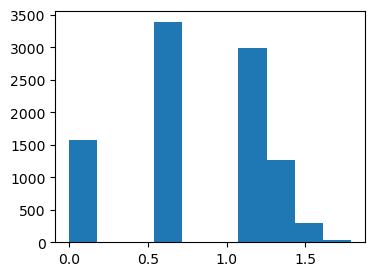

In [185]:
#transformación de la variable failed_logins

intrusion_2['failed_logins'] = np.log1p(intrusion_2['failed_logins'])
plt.figure(figsize=(4,3))
plt.hist(data=intrusion_2, x='failed_logins')

In [186]:
intrusion_2.head()

,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,308.899514,TCP,17.575537,15.902885,DES,0.474256,0.693147,Edge,0,1
1,250.467357,TCP,15.826161,22.985302,DES,0.263570,0.000000,Firefox,0,0
2,322.466710,TCP,17.957358,8.130619,DES,0.553405,1.098612,Chrome,0,1
3,400.138616,UDP,20.003465,16.974568,DES,0.116242,0.000000,Unknown,0,1
4,241.568559,TCP,15.542476,16.312775,AES,0.053421,0.693147,Firefox,0,0


### Transformación de variables categóricas

In [213]:
intrusion_encoded = pd.get_dummies(intrusion_2, columns=['protocol_type', 'encryption_used', 'browser_type'], drop_first=True)
print(f"Number of features transformed dataset: {len(intrusion_encoded.columns)}")

intrusion_encoded = intrusion_encoded.to_csv('intrusion_encoded.csv', index=False)

Number of features transformed dataset: 14


### Separación de la dataset en train/test

In [188]:
from sklearn.model_selection import train_test_split
X = intrusion_encoded.drop(['attack_detected'], axis=1)
y = intrusion_encoded['attack_detected']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Escalado de variables numéricas por estandarización

Escalado de datos de entrenamiento (train set)

In [207]:
from sklearn.preprocessing import StandardScaler

Xnum_var = list((X_train.select_dtypes(include='number')).columns)
#escalado de las variables numéricas sin incluir las codificadas por One-Hot
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[Xnum_var])
#conversión de array a pd.DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=Xnum_var, index=X_train.index)
#combinar este array con las columnas categóricas
X_train_cat = X_train.drop(columns=Xnum_var)
X_train_final = pd.concat([X_train_scaled, X_train_cat], axis=1)


EScalado de datos de prueba (test set)

In [210]:
#escalado de las variables numéricas sin incluir las codificadas por One-Hot

X_test_scaled = scaler.transform(X_test[Xnum_var])
#conversión de array a pd.DataFrame
X_test_scaled = pd.DataFrame(X_test_scaled, columns=Xnum_var, index=X_test.index)
#combinar este array con las columnas categóricas
X_test_cat = X_test.drop(columns=Xnum_var)
X_test_final = pd.concat([X_test_scaled, X_test_cat], axis=1)

Exportación de los datos de entrenamiento y prueba

In [211]:
predictors_train = X_train_final.to_csv('predictors_train.csv', index=False)
predictors_test = X_test_final.to_csv('predictors_test.csv', index=False)
labels_train = y_train.to_csv('labels_train.csv', index=False)
labels_test = y_test.to_csv('labels_test.csv', index=False)